In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In this DataLab, you will revisit one of the MLP models you developed in the previous DataLab and dive deeper.

In [2]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

2023-04-04 14:23:36.719392: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-04 14:23:36.741675: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-04 14:23:36.742257: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-04 14:23:37.183492: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


4


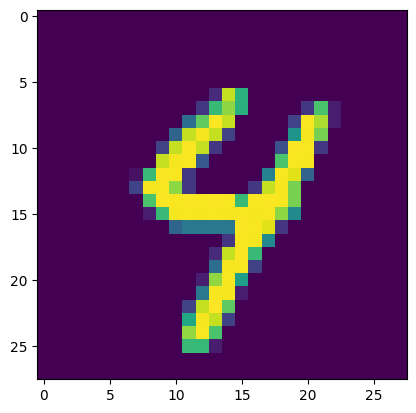

In [3]:
# random image
index = np.random.randint(0, 60000)
plt.imshow(X_train[index])
print(y_train[index])

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

## Task 1: Learning curves

**Task 1.1**

Adjust the shapes of X_train, X_test, y_train, y_test to be compatible with the network below.

<img src=https://i.imgur.com/OFNAslJ.png width="500">

In [5]:
# YOUR CODE HERE #
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

**Task 1.2**

Build the model. But this time, create a function for this task because you will have to repeat it a few times today.

In [6]:
from keras.models import Sequential
from keras.layers import Dense

def build_model(print_summary=False):
    model = Sequential()
    # YOUR CODE HERE #
    activation = 'relu'
    model.add(Dense(30, input_shape=(784,), activation=activation))
    model.add(Dense(30, activation=activation))
    model.add(Dense(10, activation='sigmoid'))
    
    # display summary is optional
    if print_summary:
        model.summary()
    return model

model = build_model(print_summary=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 30)                23550     
                                                                 
 dense_1 (Dense)             (None, 30)                930       
                                                                 
 dense_2 (Dense)             (None, 10)                310       
                                                                 
Total params: 24,790
Trainable params: 24,790
Non-trainable params: 0
_________________________________________________________________


2023-04-04 14:23:38.059936: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-04-04 14:23:38.060319: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


**Task 1.3**

Compile the model. Similarly, create a function for this task. In this DataLab we will use the Adam optimizer.

During compilation, we can define an optimizer as `model.compile(optimizer='adam', ...)`

This is a good starting point, but it does not let us configure the optimizer. Most importantly, when we want to change the learning rate. 

To achieve this, you can do the following:

`from keras.optimizers import Adam
opt = Adam(lr=0.001)
model.compile(optimizer=opt, ...)`

now this will let you change the learning rate.

Note:

If importing `Adam` gives an error try the following instead:

`from tensorflow.keras.optimizers import Adam`

In [7]:
from keras.optimizers import Adam
def compile_model(model, lr):
    # YOUR CODE HERE #
    opt = Adam(lr=lr)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = compile_model(model, lr=0.001)

/home/jupyter/.local/lib/python3.10/site-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


**Task 1.4**

Train the model for 5 epochs. This time save the history `H = model.fit(...)`.

In [8]:
# YOUR CODE HERE #

H = model.fit(X_train, y_train, epochs = 5, validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 [==============================] - 1s 654us/step - loss: 1.5048 - accuracy: 0.7138 - val_loss: 0.5251 - val_accuracy: 0.8759
Epoch 2/5
1875/1875 [==============================] - 1s 600us/step - loss: 0.4653 - accuracy: 0.8863 - val_loss: 0.4163 - val_accuracy: 0.9018
Epoch 3/5
1875/1875 [==============================] - 1s 606us/step - loss: 0.3969 - accuracy: 0.9059 - val_loss: 0.3671 - val_accuracy: 0.9095
Epoch 4/5
1875/1875 [==============================] - 1s 605us/step - loss: 0.3538 - accuracy: 0.9147 - val_loss: 0.3926 - val_accuracy: 0.9116
Epoch 5/5
1875/1875 [==============================] - 1s 605us/step - loss: 0.3210 - accuracy: 0.9212 - val_loss: 0.3220 - val_accuracy: 0.9237


**Task 1.5**

Evaluate the model using `model.evaluate()`.

In [9]:
val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss, val_acc)

313/313 [==============================] - 0s 396us/step - loss: 0.3220 - accuracy: 0.9237
0.3220006227493286 0.9236999750137329


**Task 1.6**

Plot the learning curves for `loss` and `val_loss`. Example output:

<img src=https://i.imgur.com/74WymKX.png width="500">

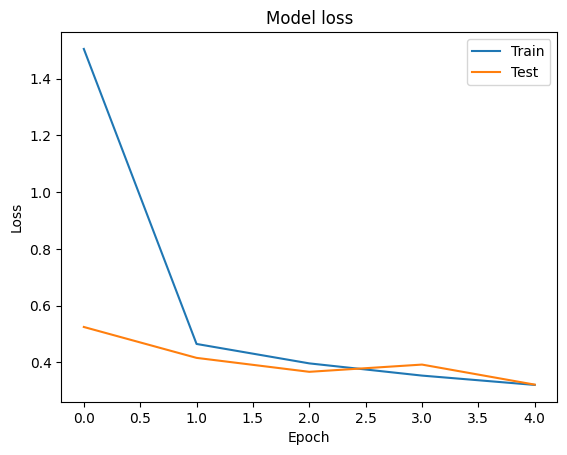

In [10]:
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    # Make it pretty
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    # YOUR CODE HERE #

loss_plotter(H)

**Task 1.7**

Plot the learning curves for `accuracy` and `val_accuracy`. Example output:

<img src=https://i.imgur.com/Md9JIHh.png width="500">

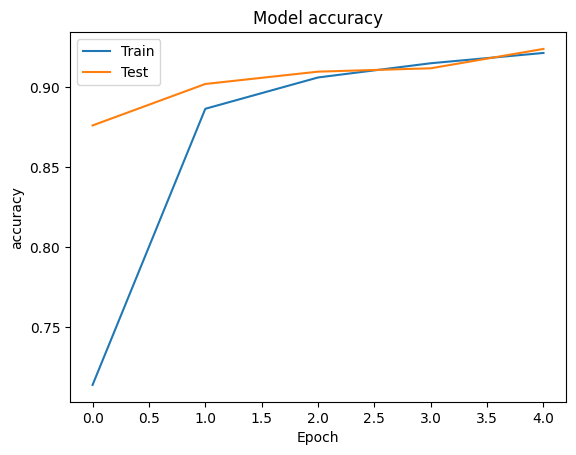

In [11]:
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    
accuracy_plotter(H)

## Task 2: EarlyStopping

In [12]:
# Use the functions you created in task 1.
model = build_model()
model = compile_model(model, lr=0.001)

**Task 2.1**

Now instead of setting a fixed number of epochs, use `EarlyStopping` callback. Monitor the validation loss with a patience of 2. Remember to restore the best weights.

In [13]:
from keras.callbacks import EarlyStopping
# YOUR CODE HERE #
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                       patience=2)

**Note:** When using early stopping, you still need to set the number of epochs for training. Let's say you set the epochs to 10, and the model ran for 10 epochs. This means the stopping conditions you set in the callback did not occur therefore the training ran until the end. If the training runs for less than 10 epochs, this means early stopping kicked in.

**Task 2.2**

Train the model with the callback you created in Task 2.1. From now on, always store the history `H = model.fit()`. Set the number of epochs such that you can observe early stopping.

In [14]:
# YOUR CODE HERE #

H = model.fit(X_train, y_train, epochs = 10,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc])

Epoch 1/10
1875/1875 [==============================] - 1s 641us/step - loss: 1.7276 - accuracy: 0.5870 - val_loss: 0.8343 - val_accuracy: 0.7159
Epoch 2/10
1875/1875 [==============================] - 1s 617us/step - loss: 0.6188 - accuracy: 0.8326 - val_loss: 0.5552 - val_accuracy: 0.8718
Epoch 3/10
1875/1875 [==============================] - 1s 612us/step - loss: 0.4764 - accuracy: 0.8819 - val_loss: 0.4711 - val_accuracy: 0.8881
Epoch 4/10
1875/1875 [==============================] - 1s 619us/step - loss: 0.3989 - accuracy: 0.9041 - val_loss: 0.3652 - val_accuracy: 0.9109
Epoch 5/10
1875/1875 [==============================] - 1s 612us/step - loss: 0.3551 - accuracy: 0.9141 - val_loss: 0.3441 - val_accuracy: 0.9116
Epoch 6/10
1875/1875 [==============================] - 1s 617us/step - loss: 0.3220 - accuracy: 0.9197 - val_loss: 0.3522 - val_accuracy: 0.9179
Epoch 7/10
1875/1875 [==============================] - 1s 619us/step - loss: 0.3038 - accuracy: 0.9238 - val_loss: 0.3149 -

**Task 2.3**

Plot the learning curves. Interpret your results.

- Compare these to the learning curves from Task 1
- Did the model train for more than 5 epochs? yes
- Did the performance improve? ~
- Do you think the model is overfitting? may start overfitting but not yet

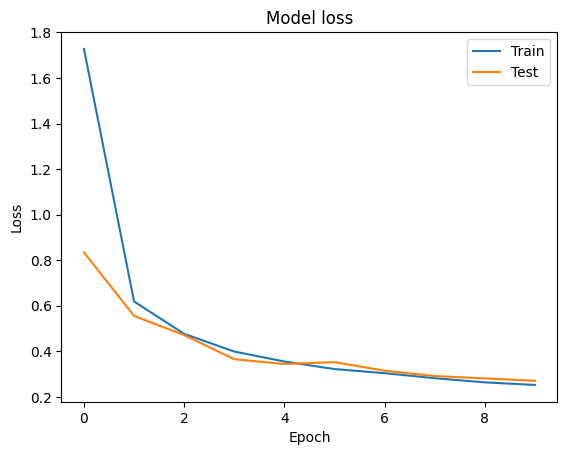

In [15]:
loss_plotter(H)

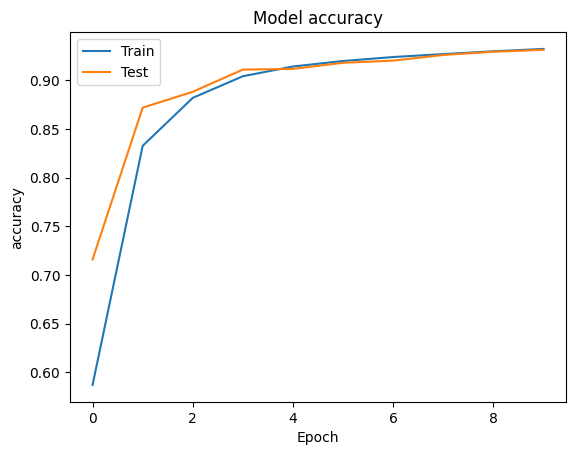

In [16]:
accuracy_plotter(H)

## Task 3: Tuning learning rate

Train your model with 5 different learning rates.

Epoch 1/10
1875/1875 [==============================] - 1s 645us/step - loss: 1.9749 - accuracy: 0.3575 - val_loss: 1.4954 - val_accuracy: 0.4315
Epoch 2/10
1875/1875 [==============================] - 1s 611us/step - loss: 1.4917 - accuracy: 0.4221 - val_loss: 1.4831 - val_accuracy: 0.4250
Epoch 3/10
1875/1875 [==============================] - 1s 613us/step - loss: 1.7958 - accuracy: 0.3008 - val_loss: 1.9863 - val_accuracy: 0.2303
Epoch 4/10
1875/1875 [==============================] - 1s 613us/step - loss: 1.9361 - accuracy: 0.2545 - val_loss: 1.7748 - val_accuracy: 0.2817


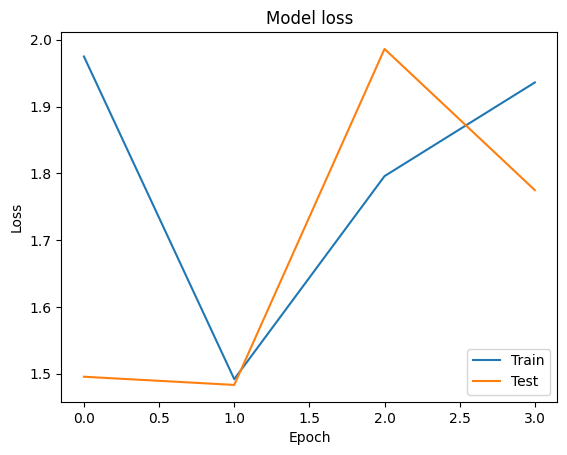

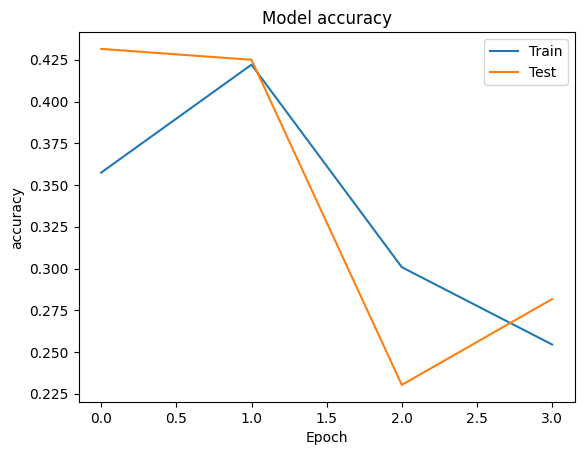

Epoch 1/10
1875/1875 [==============================] - 1s 648us/step - loss: 1.6528 - accuracy: 0.7195 - val_loss: 0.5960 - val_accuracy: 0.8445
Epoch 2/10
1875/1875 [==============================] - 1s 619us/step - loss: 0.5072 - accuracy: 0.8633 - val_loss: 0.4783 - val_accuracy: 0.8862
Epoch 3/10
1875/1875 [==============================] - 1s 615us/step - loss: 0.4176 - accuracy: 0.8892 - val_loss: 0.3712 - val_accuracy: 0.9107
Epoch 4/10
1875/1875 [==============================] - 1s 615us/step - loss: 0.3729 - accuracy: 0.9031 - val_loss: 0.3770 - val_accuracy: 0.9129
Epoch 5/10
1875/1875 [==============================] - 1s 608us/step - loss: 0.3391 - accuracy: 0.9124 - val_loss: 0.3768 - val_accuracy: 0.9076


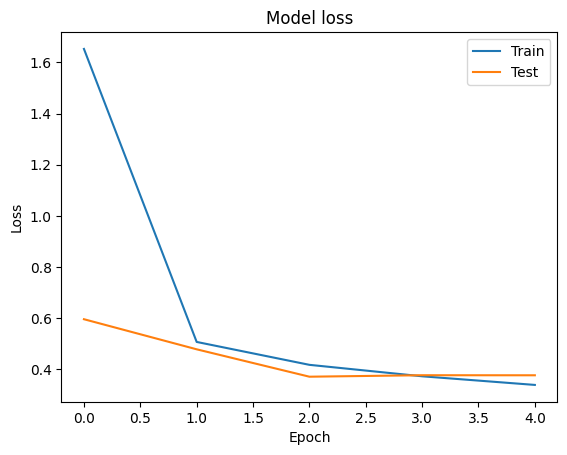

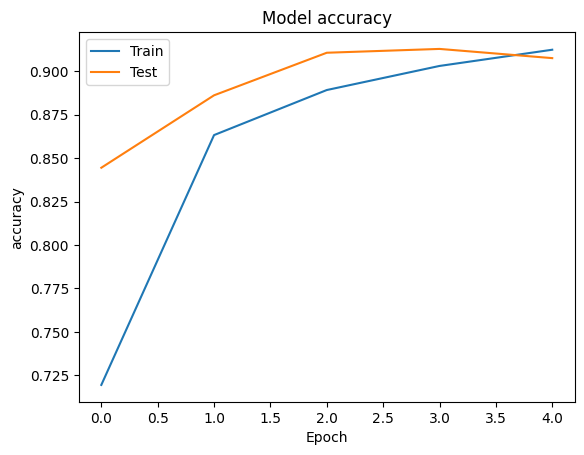

Epoch 1/10
1875/1875 [==============================] - 1s 655us/step - loss: 7.0380 - accuracy: 0.4669 - val_loss: 1.6304 - val_accuracy: 0.5248
Epoch 2/10
1875/1875 [==============================] - 1s 618us/step - loss: 1.3624 - accuracy: 0.6409 - val_loss: 1.0574 - val_accuracy: 0.7183
Epoch 3/10
1875/1875 [==============================] - 1s 621us/step - loss: 0.9557 - accuracy: 0.7500 - val_loss: 0.7831 - val_accuracy: 0.7914
Epoch 4/10
1875/1875 [==============================] - 1s 619us/step - loss: 0.7342 - accuracy: 0.8039 - val_loss: 0.6431 - val_accuracy: 0.8327
Epoch 5/10
1875/1875 [==============================] - 1s 616us/step - loss: 0.6014 - accuracy: 0.8372 - val_loss: 0.5391 - val_accuracy: 0.8582
Epoch 6/10
1875/1875 [==============================] - 1s 617us/step - loss: 0.5066 - accuracy: 0.8620 - val_loss: 0.4792 - val_accuracy: 0.8773
Epoch 7/10
1875/1875 [==============================] - 1s 621us/step - loss: 0.4388 - accuracy: 0.8808 - val_loss: 0.4265 -

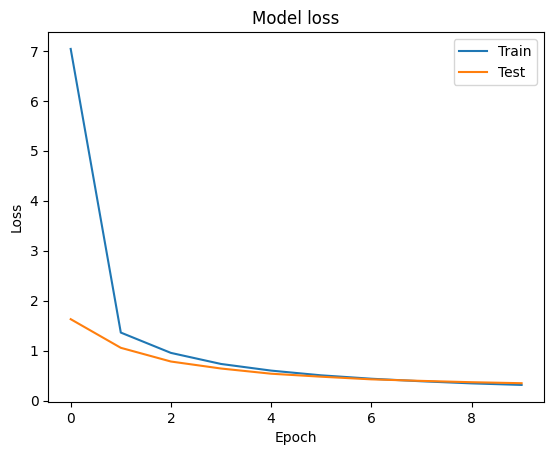

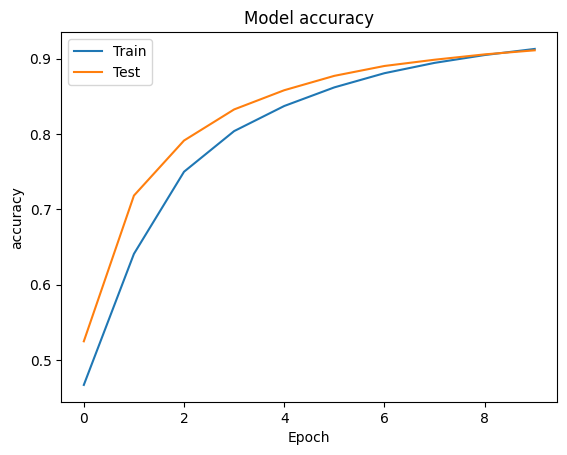

Epoch 1/10
1875/1875 [==============================] - 1s 652us/step - loss: 29.9064 - accuracy: 0.2247 - val_loss: 12.2515 - val_accuracy: 0.3433
Epoch 2/10
1875/1875 [==============================] - 1s 613us/step - loss: 7.5699 - accuracy: 0.3897 - val_loss: 4.2731 - val_accuracy: 0.4196
Epoch 3/10
1875/1875 [==============================] - 1s 620us/step - loss: 3.1614 - accuracy: 0.4277 - val_loss: 2.3655 - val_accuracy: 0.4172
Epoch 4/10
1875/1875 [==============================] - 1s 613us/step - loss: 2.1607 - accuracy: 0.4250 - val_loss: 1.9062 - val_accuracy: 0.4345
Epoch 5/10
1875/1875 [==============================] - 1s 614us/step - loss: 1.8260 - accuracy: 0.4610 - val_loss: 1.7006 - val_accuracy: 0.4732
Epoch 6/10
1875/1875 [==============================] - 1s 613us/step - loss: 1.6472 - accuracy: 0.4955 - val_loss: 1.5692 - val_accuracy: 0.5088
Epoch 7/10
1875/1875 [==============================] - 1s 618us/step - loss: 1.5265 - accuracy: 0.5278 - val_loss: 1.4651

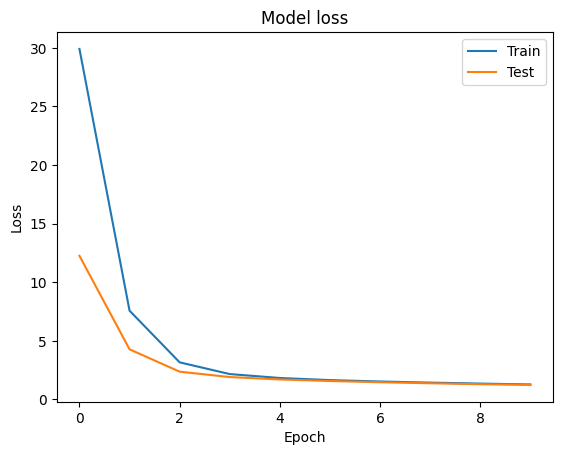

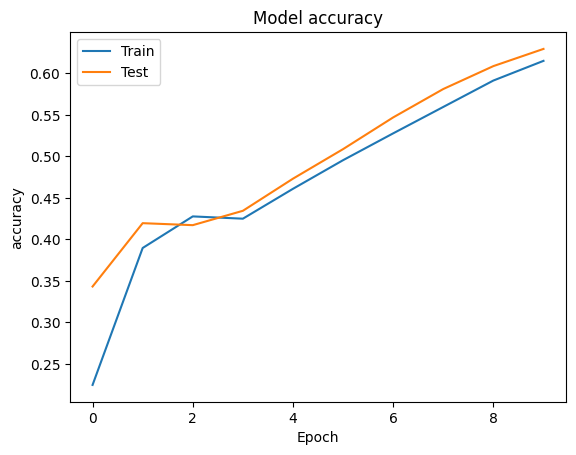

Epoch 1/10
1875/1875 [==============================] - 1s 650us/step - loss: 72.9634 - accuracy: 0.1227 - val_loss: 62.2831 - val_accuracy: 0.1311
Epoch 2/10
1875/1875 [==============================] - 1s 618us/step - loss: 53.3544 - accuracy: 0.1506 - val_loss: 47.6407 - val_accuracy: 0.1577
Epoch 3/10
1875/1875 [==============================] - 1s 614us/step - loss: 41.6875 - accuracy: 0.1786 - val_loss: 37.5694 - val_accuracy: 0.1893
Epoch 4/10
1875/1875 [==============================] - 1s 611us/step - loss: 33.3133 - accuracy: 0.2116 - val_loss: 30.2183 - val_accuracy: 0.2236
Epoch 5/10
1875/1875 [==============================] - 1s 614us/step - loss: 27.1862 - accuracy: 0.2463 - val_loss: 24.8411 - val_accuracy: 0.2607
Epoch 6/10
1875/1875 [==============================] - 1s 616us/step - loss: 22.7103 - accuracy: 0.2847 - val_loss: 20.9406 - val_accuracy: 0.2985
Epoch 7/10
1875/1875 [==============================] - 1s 614us/step - loss: 19.4199 - accuracy: 0.3199 - val_l

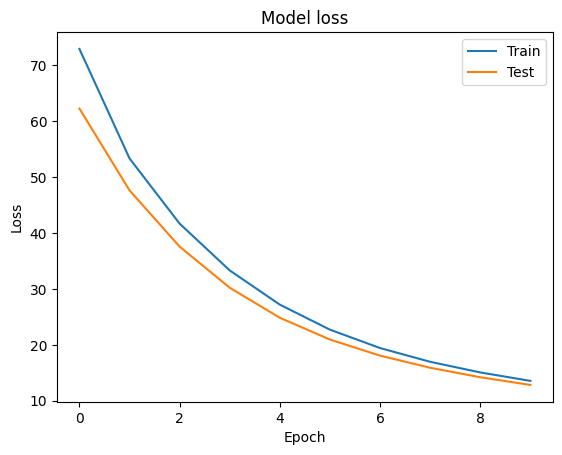

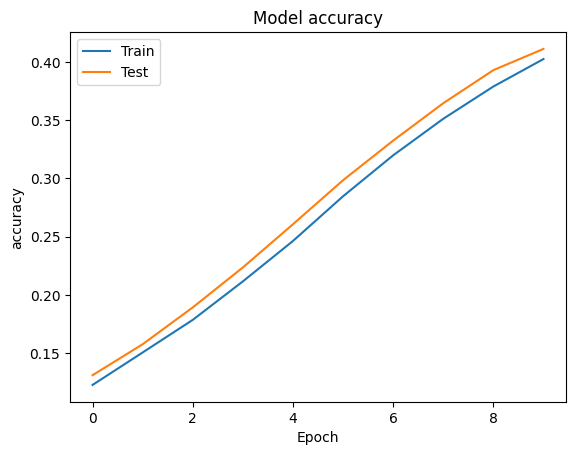

In [17]:
learning_rates = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
for lr in learning_rates:
    model = build_model()
    model = compile_model(model, lr=lr)
    H = model.fit(X_train, y_train, epochs = 10,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc])
    loss_plotter(H)
    accuracy_plotter(H)

Use the early stopping callback you created in Task 2. When you are training the models, save each history object. Set the number of epochs to a large enough number such that early stopping occurs in some of the learning rates.

**Task 3.1** Plot `val_loss` vs epochs for each learning rate.

Example output:

<img src=https://i.imgur.com/CPqfa3j.png width="500">

closer look:

<img src=https://i.imgur.com/BvSZA0s.png width="500">


These plots show which learning rate(s) are a good choice. But we can plot the best loss vs learning rate to see the relationship even better. 

**Task 3.2** Plot best validation loss vs learning rate.

Example output:

<img src=https://i.imgur.com/xSgQbyZ.png width="500">

Notice that we can use the validation loss obtained at the end of training (last epoch). But that is not necessarily the best. In fact, we are using early stopping for this reason: when the model is not improving, stop with a patience. If you configured the callback correctly, it returns the best model. 
- You can use `model.evaluate()` to calculate the best validation loss.
- Alternatively, since patience is 2, the 3<sup>rd</sup> validation loss from the last must be the best loss in the history.

In [18]:
histories = [] # for plotting val_loss vs epochs for each learning rate
best_val_losses = [] # for plotting best_val_loss vs learning rate

for lr in learning_rates:
    print('Training with: ', lr)
    model = build_model()
    model = compile_model(model, lr=lr)
    
    H = model.fit(X_train, y_train, epochs = 10,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc])
    
    best_loss = # YOUR CODE HERE #
    
    best_val_losses.append(best_loss)
    histories.append(H)

SyntaxError: invalid syntax (3291653396.py, line 13)

In [ ]:
# TASK 3.1 #
# Plot validation loss vs. epochs for each learning rate #
histories
'''
plt.plot(histories)
plt.show()

In [ ]:
# TASK 3.2 #
# Plot best validation loss vs learning rate # 

## Task 4: Creative Brief

Apply what you have learned to your creative brief.

- Plot learning curves
- Use early stopping
- Train your model with different learning rates